In [28]:
from pilotpy.tools import *
import scanpy as sc
#from pilot_gm_vae import *

In [29]:
import os
desired_path = '/data/scRNA/To_Mehdi/pan_data/rebuttal_science/2026-04-10/' # Or the folder your current notebook is in
os.chdir(desired_path)

In [30]:
file_path = 'snRNA_new_new_filtered.h5ad'
hs_snrna=sc.read_h5ad(file_path)

In [31]:
file_path = 'embryo_snrna_filtered_2.h5ad'
embryo_snrna=sc.read_h5ad(file_path)

In [33]:
file_path = 'mm_snrna_filtered_2.h5ad'
mm_snrna=sc.read_h5ad(file_path)

In [5]:
#file_path = 'ipsc.h5ad'
#ipsc=sc.read_h5ad(file_path)

In [ ]:
#file_path = 'adult_FACS_sorted_filtered.h5ad'
#sorted_data=sc.read_h5ad(file_path)

In [32]:
file_path = 'rn_snrna_filtered_50_2.h5ad'
rn_snrna=sc.read_h5ad(file_path)

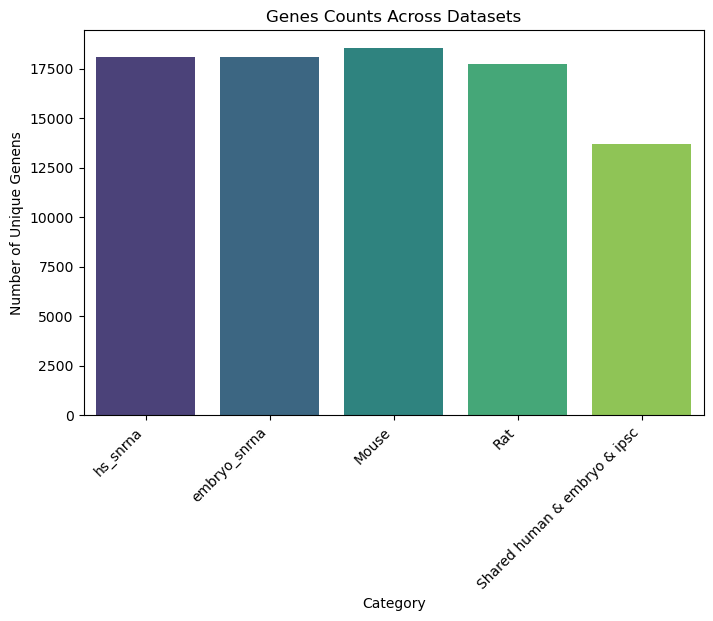

In [34]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming adata1, adata2, and adata3 are your AnnData objects
donors_1 = set(hs_snrna.var_names.str.upper())
donors_2 = set(embryo_snrna.var_names.str.upper())
#donors_4 = set(sorted_data.var_names.str.upper())
donors_5 = set(rn_snrna.var_names.str.upper())
donors_3 = set(mm_snrna.var_names.str.upper())

# Find shared donors
shared_12 = donors_1 & donors_2  & donors_5 & donors_3

# Count occurrences
counts = {
    "hs_snrna": len(donors_1),
    "embryo_snrna": len(donors_2),
     "Mouse": len(donors_3),
     "Rat": len(donors_5),

    "Shared human & embryo & ipsc": len(shared_12),
}

# Convert to DataFrame
df = pd.DataFrame(list(counts.items()), columns=["Category", "Count"])

# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Category", y="Count", palette="viridis")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Unique Genens")
plt.title("Genes Counts Across Datasets")
plt.show()


In [35]:
hs_snrna.var_names=hs_snrna.var_names.str.upper()
embryo_snrna.var_names=embryo_snrna.var_names.str.upper()
#hs_snrna_2.var_names=hs_snrna_2.var_names.str.upper()
#sorted_data.var_names=sorted_data.var_names.str.upper()
rn_snrna.var_names=rn_snrna.var_names.str.upper()
mm_snrna.var_names=mm_snrna.var_names.str.upper()

In [36]:
hs_snrna_filtered = hs_snrna[:, list(shared_12)].copy()
embryo_snrna_filtered = embryo_snrna[:, list(shared_12)].copy()
#hs_snrna_2_filtered = hs_snrna_2[:, list(shared_12)].copy()
#sorted_data_filtered = sorted_data[:, list(shared_12)].copy()
rn_snrna_filtered = rn_snrna[:, list(shared_12)].copy()
mm_snrna_filtered = mm_snrna[:, list(shared_12)].copy()

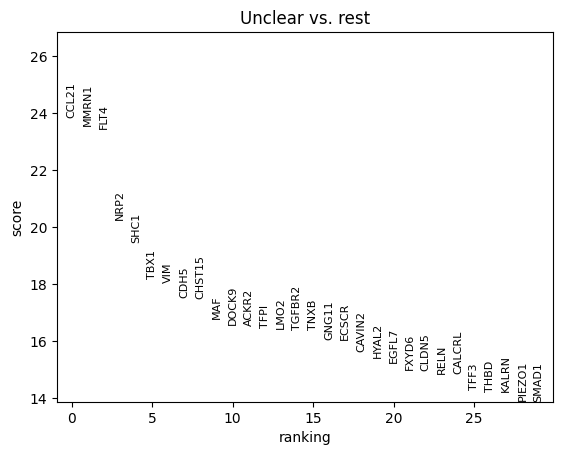

In [32]:
import scanpy as sc

# Make sure you use log-normalized data, not raw counts
sc.tl.rank_genes_groups(
    sorted_data_filtered,
    groupby="cell_subtype",
    groups=["Unclear"],
    reference="rest",
    method="wilcoxon"
)

sc.pl.rank_genes_groups(
    sorted_data_filtered,
    groups=["Unclear"],
    n_genes=30,
    sharey=False
)

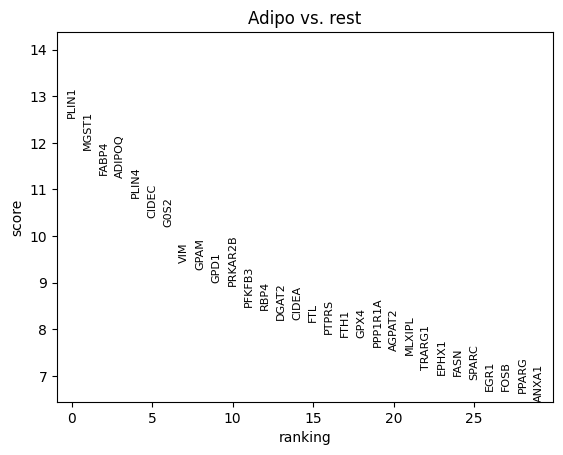

In [33]:
import scanpy as sc

# Make sure you use log-normalized data, not raw counts
sc.tl.rank_genes_groups(
    sorted_data_filtered,
    groupby="cell_subtype",
    groups=["Adipo"],
    reference="rest",
    method="wilcoxon"
)

sc.pl.rank_genes_groups(
    sorted_data_filtered,
    groups=["Adipo"],
    n_genes=30,
    sharey=False
)

In [11]:
list(embryo_snrna_filtered.obs['cell_type_new'].unique())

['Differentiating LV-CMs',
 'Trabecular LV-CMs',
 'Immature LV-CMs',
 'Cell cycle LV-CMs',
 'Stress-responsive LV-CMs',
 'Mature LV-CMs',
 'Immune cells',
 'Fibroblasts',
 'Mural cells',
 'Endothelial cells',
 'Neuronal cells']

In [37]:
hs_snrna_filtered.obs['Donor'] = hs_snrna_filtered.obs['Donor']
hs_snrna_filtered.obs['Dataset'] = 'human'
embryo_snrna_filtered.obs['Donor'] = embryo_snrna_filtered.obs['Donor']   
embryo_snrna_filtered.obs['Dataset'] = 'embryo'
#hs_snrna_2_filtered.obs['Donor'] = hs_snrna_2_filtered.obs['Sample']    
#hs_snrna_2_filtered.obs['Dataset'] = 'human'
rn_snrna_filtered.obs['Donor'] = rn_snrna_filtered.obs['Sample']  
rn_snrna_filtered.obs['Dataset'] = 'Rat'
mm_snrna_filtered.obs['Donor'] = mm_snrna_filtered.obs['Sample']  
mm_snrna_filtered.obs['Dataset'] = 'Mouse'

#sorted_data_filtered.obs['Donor'] = sorted_data_filtered.obs['Sample']  
#sorted_data_filtered.obs['Dataset'] = 'sorted'

In [13]:
#hs_snrna_2_filtered.obs['diagnosis_CK']='control'

In [38]:
donor_combined = np.concatenate([hs_snrna_filtered.obs['Donor'].values, embryo_snrna_filtered.obs['Donor'].values,mm_snrna_filtered.obs['Donor'].values,rn_snrna_filtered.obs['Donor'].values])
status_combined = np.concatenate([hs_snrna_filtered.obs['diagnosis_CK'].values, embryo_snrna_filtered.obs['diagnosis_CK'].values,mm_snrna_filtered.obs['diagnosis_CK'], rn_snrna_filtered.obs['treatment_group']])
Dataset = np.concatenate([hs_snrna_filtered.obs['Dataset'].values, embryo_snrna_filtered.obs['Dataset'].values,mm_snrna_filtered.obs['Dataset'].values, rn_snrna_filtered.obs['Dataset'].values])
cell_combined = np.concatenate([hs_snrna_filtered.obs['cell_subtype_merged'].values,embryo_snrna_filtered.obs['cell_subtype'].values,mm_snrna_filtered.obs['cell_subtype'].values,rn_snrna_filtered.obs['cell_subtype'].values ])
idd = np.concatenate([hs_snrna_filtered.obs.index,embryo_snrna_filtered.obs.index,mm_snrna_filtered.obs.index,rn_snrna_filtered.obs.index ])
hs_snrna_x = hs_snrna_filtered.layers['after_soupx'].toarray()  # Shape: (n_human_cells, n_genes)
embryo_snrna_x = embryo_snrna_filtered.layers['after_soupx'].toarray()  # Shape: (n_human_cells, n_genes)
#hs_snrna_2_filtered_x =hs_snrna_2_filtered.layers['after_soupx'].toarray()  # Shape: (n_human_cells, n_genes)
mm_snrna_filtered_x = mm_snrna_filtered.layers['after_soupx'].toarray()  # Shape: (n_human_cells, n_genes)
rn_snrna_filtered_x = rn_snrna_filtered.layers['after_soupx'].toarray()  # Shape: (n_human_cells, n_genes)
X_genes_combined = np.concatenate([hs_snrna_x,embryo_snrna_x,mm_snrna_filtered_x,rn_snrna_filtered_x], axis=0)

In [39]:
combined_adata = sc.AnnData(X_genes_combined)
combined_adata.obs['Donor'] = donor_combined
combined_adata.obs['status'] = status_combined
combined_adata.obs['Dataset'] = Dataset
combined_adata.obs['cell_subtype'] = cell_combined  
combined_adata.obs['index'] =idd
combined_adata.var_names=list(shared_12)
combined_adata.layers["counts"] = combined_adata.X.copy()

In [40]:
combined_adata.obs['Dataset'].unique()


array(['human', 'embryo', 'Mouse', 'Rat'], dtype=object)

In [41]:
combined_adata.write_h5ad('/data/scRNA/To_Mehdi/pan_data/rebuttal_science/2026-04-10/combined_Rat_Human_Mouse_Embryo.h5ad')

In [24]:
adata__ = combined_adata[
    (
        (combined_adata.obs["cell_subtype"] == "Cell cycle LV-CMs") &
        (combined_adata.obs["Dataset"] == "embryo")
    )
].copy()

In [26]:
adata__.obs['cell_subtype'].unique()

['Cell cycle LV-CMs']
Categories (1, object): ['Cell cycle LV-CMs']

In [ ]:
#main_data=sc.read('/data/scRNA/To_Mehdi/pan_data/rebuttal_science/2026-04-10/combined_human.h5ad')

In [31]:
combined_adata.X=combined_adata.layers['counts'].copy()

In [30]:
combined_adata.X=combined_adata.layers['counts']

### Test

In [4]:
adata=sc.read_h5ad('/data/scRNA/To_Mehdi/Emilia/new_data/combined_human_mice_v0.h5ad')
EMD = np.load('/data/scRNA/To_Mehdi/Emilia/new_data/trained_models/snRNA_human_mice/EMD_20_combined.npy')
z_laten = np.load('/data/scRNA/To_Mehdi/Emilia/new_data/trained_models/snRNA_human_mice/z_laten_20_combined.npy')
component_assignment = np.load('/data/scRNA/To_Mehdi/Emilia/new_data/trained_models/snRNA_human_mice/component_assignment_20_combined.npy')
adata.uns['EMD'] = EMD
adata.obsm['z_laten'] = z_laten
adata.obs['component_assignment'] = component_assignment

In [5]:
adata

AnnData object with n_obs × n_vars = 183857 × 15262
    obs: 'Donor', 'status', 'batch', 'cell_subtype', 'major_celltype', 'component_assignment'
    uns: 'EMD', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_har', 'X_umap_z_laten', 'z_laten'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [ ]:
#adata.obsm['X_umap_har'] = adata.obsm['X_umap'].copy()
#sc.pp.neighbors(adata, use_rep='z_laten')
#sc.tl.umap(adata)
#adata.obsm['X_umap_z_laten'] = adata.obsm['X_umap'].copy()

In [ ]:
#adata.write_h5ad('/data/scRNA/To_Mehdi/Emilia/new_data/combined_human_mice_v0.h5ad')

In [6]:
adata

AnnData object with n_obs × n_vars = 183857 × 15262
    obs: 'Donor', 'status', 'batch', 'cell_subtype', 'major_celltype', 'component_assignment'
    uns: 'EMD', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_har', 'X_umap_z_laten', 'z_laten'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

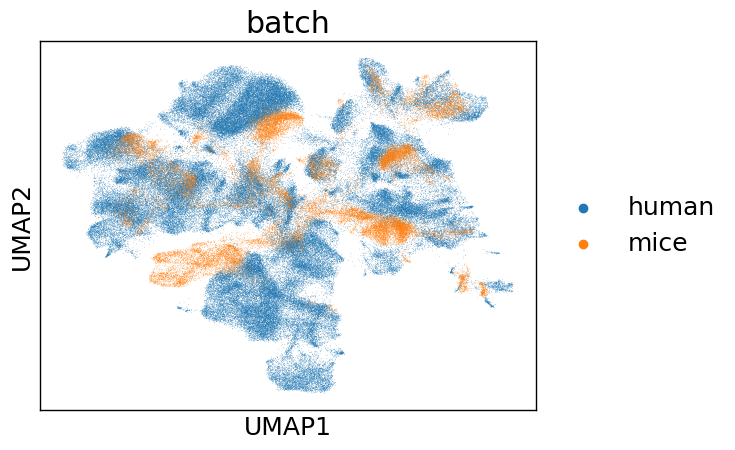

In [176]:
adata.obsm['X_umap']=adata.obsm['X_umap_z_laten']
sc.pl.umap(adata,color='batch')

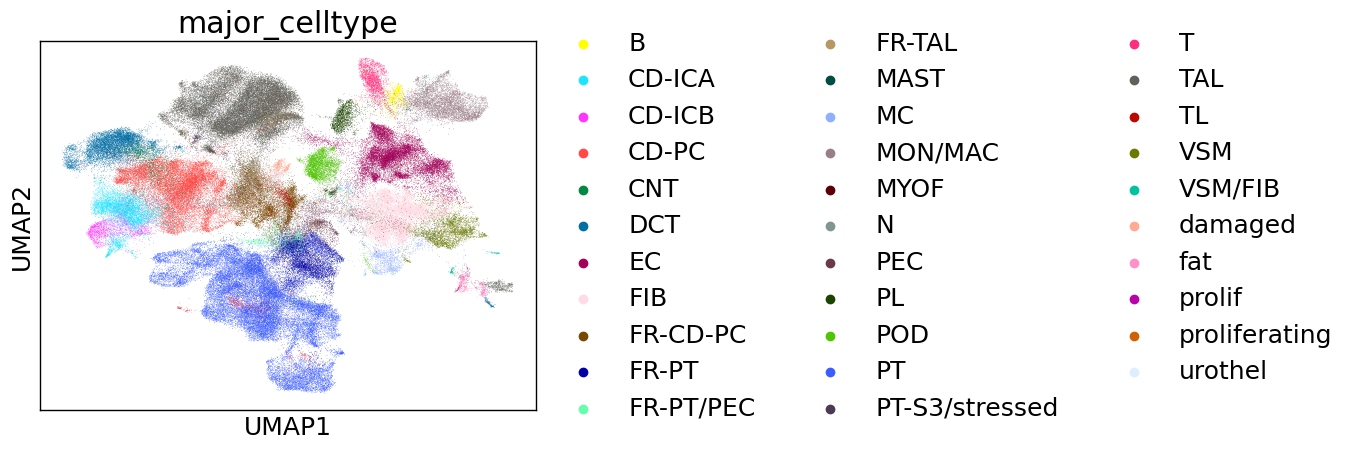

In [177]:
sc.pl.umap(adata,color='major_celltype')

In [180]:
adata.obs['component_assignment']=adata.obs['component_assignment'].astype(str)

In [ ]:
plot_umap_and_stacked_bar(adata_mice,component_col='component_assignment',cell_type_col='major_cell_type')

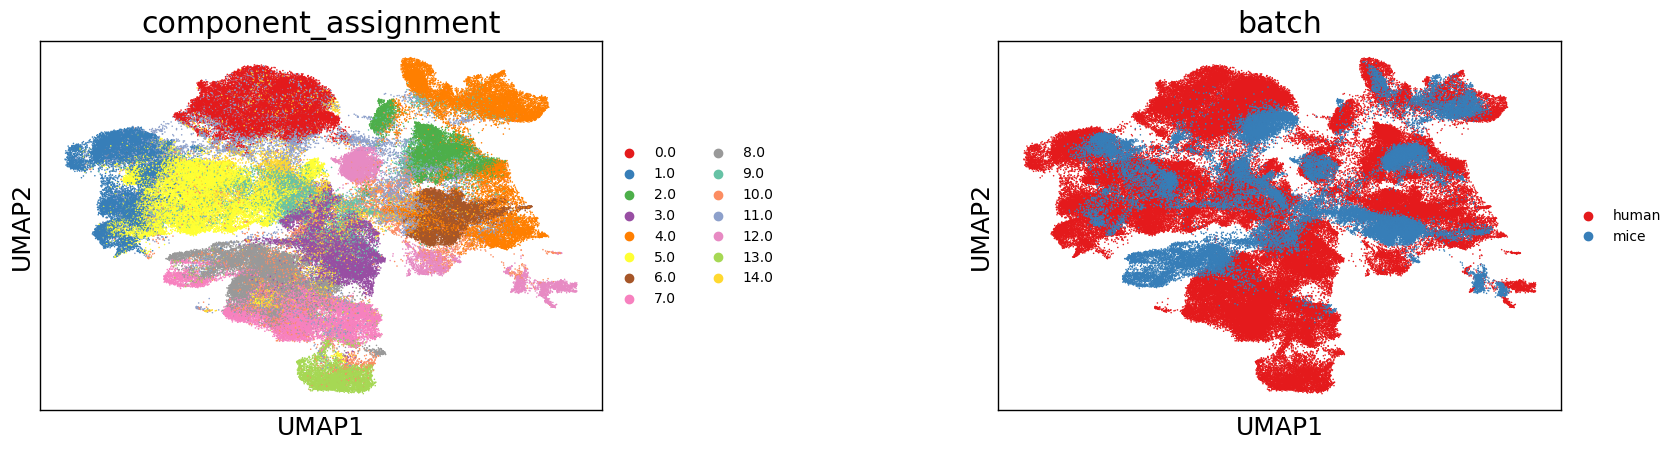

<Figure size 1400x800 with 0 Axes>

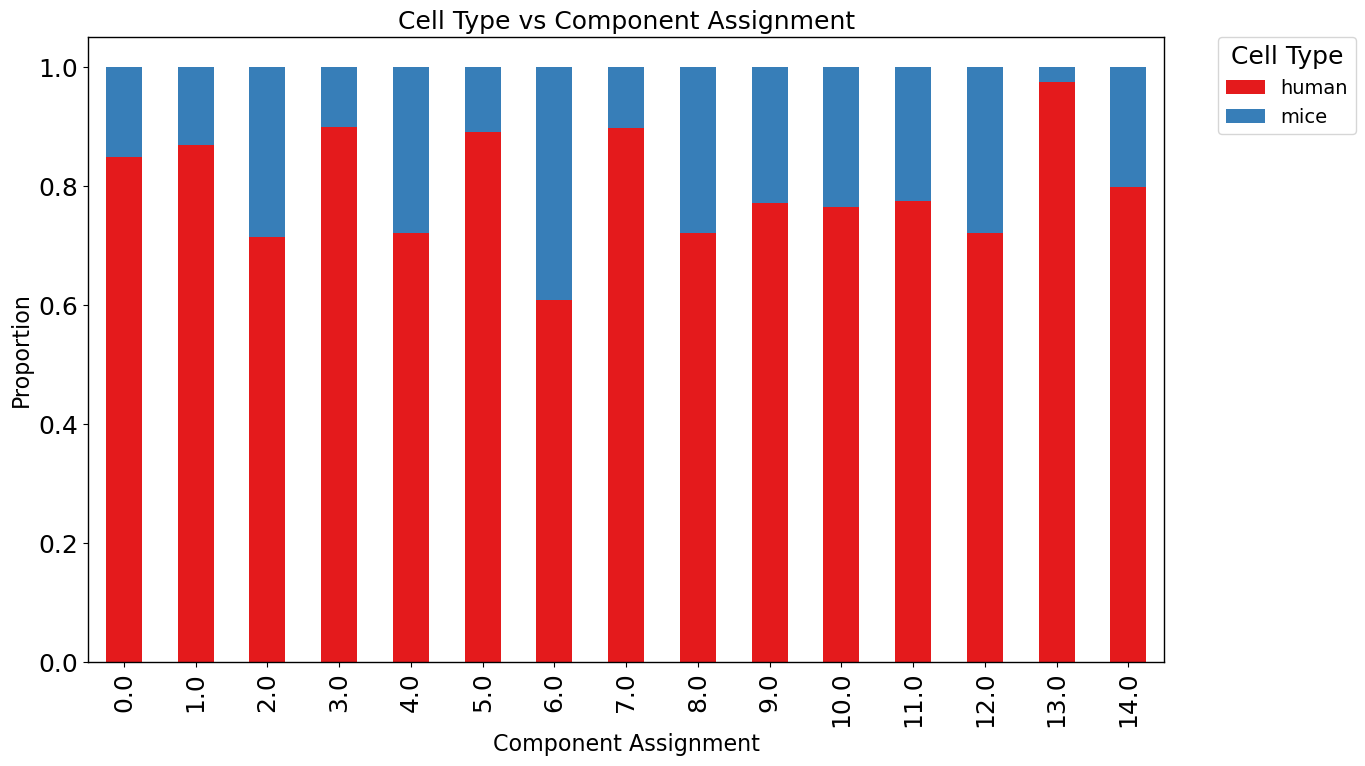

In [224]:
plot_umap_and_stacked_bar(adata,component_col='component_assignment',cell_type_col='batch')

In [227]:
adata

AnnData object with n_obs × n_vars = 183857 × 15262
    obs: 'Donor', 'status', 'batch', 'cell_subtype', 'major_celltype', 'component_assignment'
    uns: 'log1p', 'neighbors', 'pca', 'umap', 'EMD', 'batch_colors', 'major_celltype_colors', 'component_assignment_colors', 'data', 'annot', 'proportions', 'cost', 'EMD_df', 'real_labels', 'embedding', 'pseudotime', 'cellnames', 'orders'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'z_laten', 'X_umap_har', 'X_umap_z_laten'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

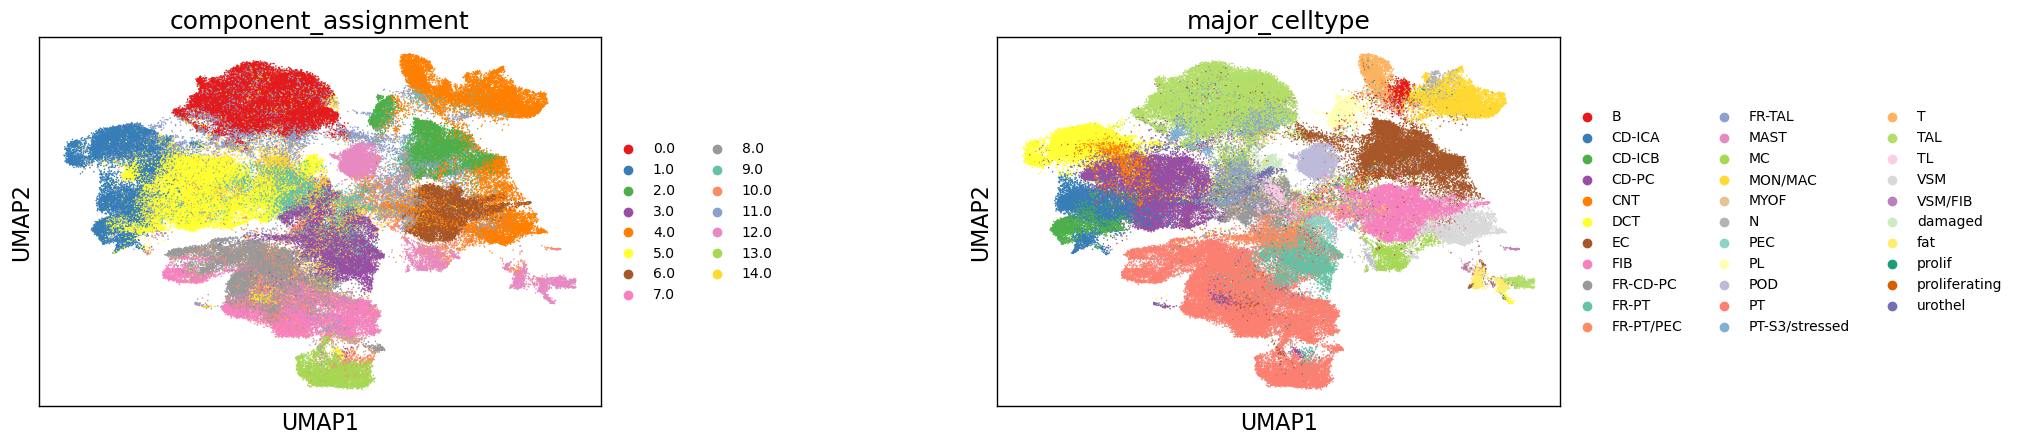

<Figure size 1400x800 with 0 Axes>

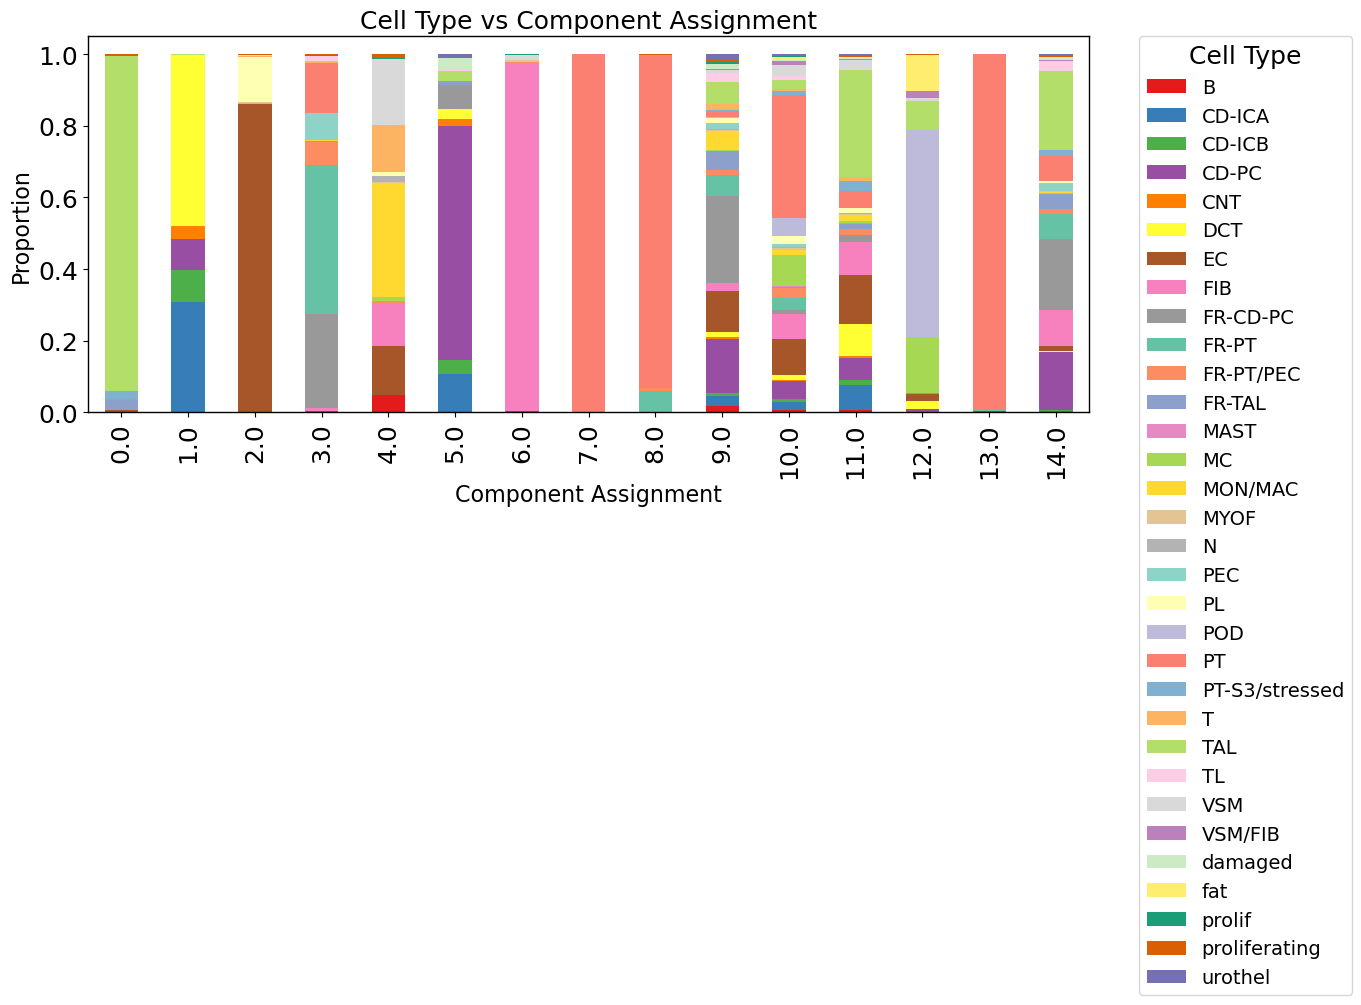

In [226]:
plot_umap_and_stacked_bar(adata,component_col='component_assignment',cell_type_col='major_celltype')

In [7]:
adata

AnnData object with n_obs × n_vars = 183857 × 15262
    obs: 'Donor', 'status', 'batch', 'cell_subtype', 'major_celltype', 'component_assignment'
    uns: 'EMD', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_har', 'X_umap_z_laten', 'z_laten'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [16]:
wasserstein_distance(adata,emb_matrix='X_pca_harmony',
clusters_col='component_assignment',sample_col='Donor',status='status',metric='cosine')

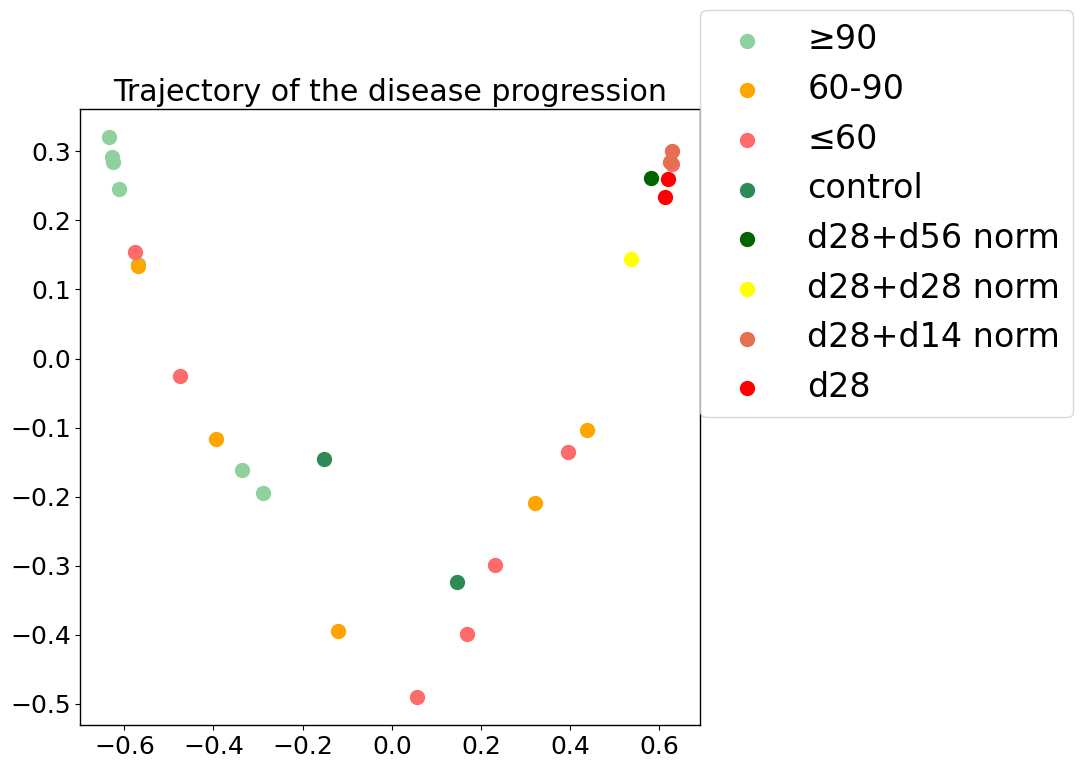

In [18]:
trajectory(adata,colors=['#8fd19e','orange','#ff6b6b','#2e8b57','darkgreen','yellow','#e76f51','red'],label_act=False,font_size=18,knn=12,figsize=(8,8),legend_order=['≥90','60-90','≤60', 'control','d28+d56 norm','d28+d28 norm','d28+d14 norm','d28'], location_labels=(1,0.5))

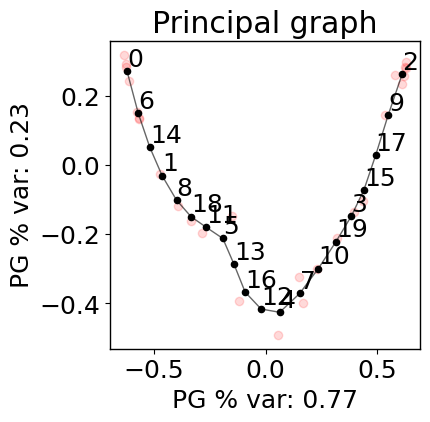

In [219]:
fit_pricipla_graph(adata, source_node =0,figsize=(4,4))

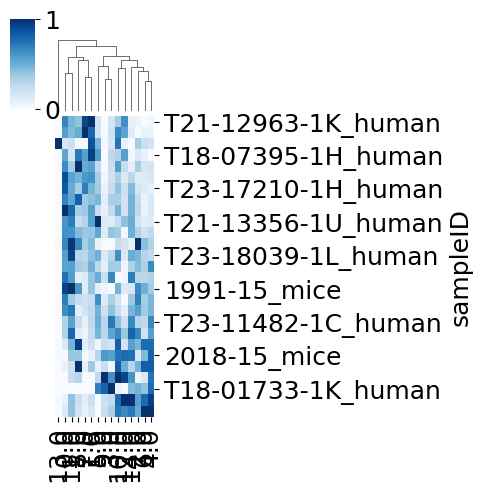

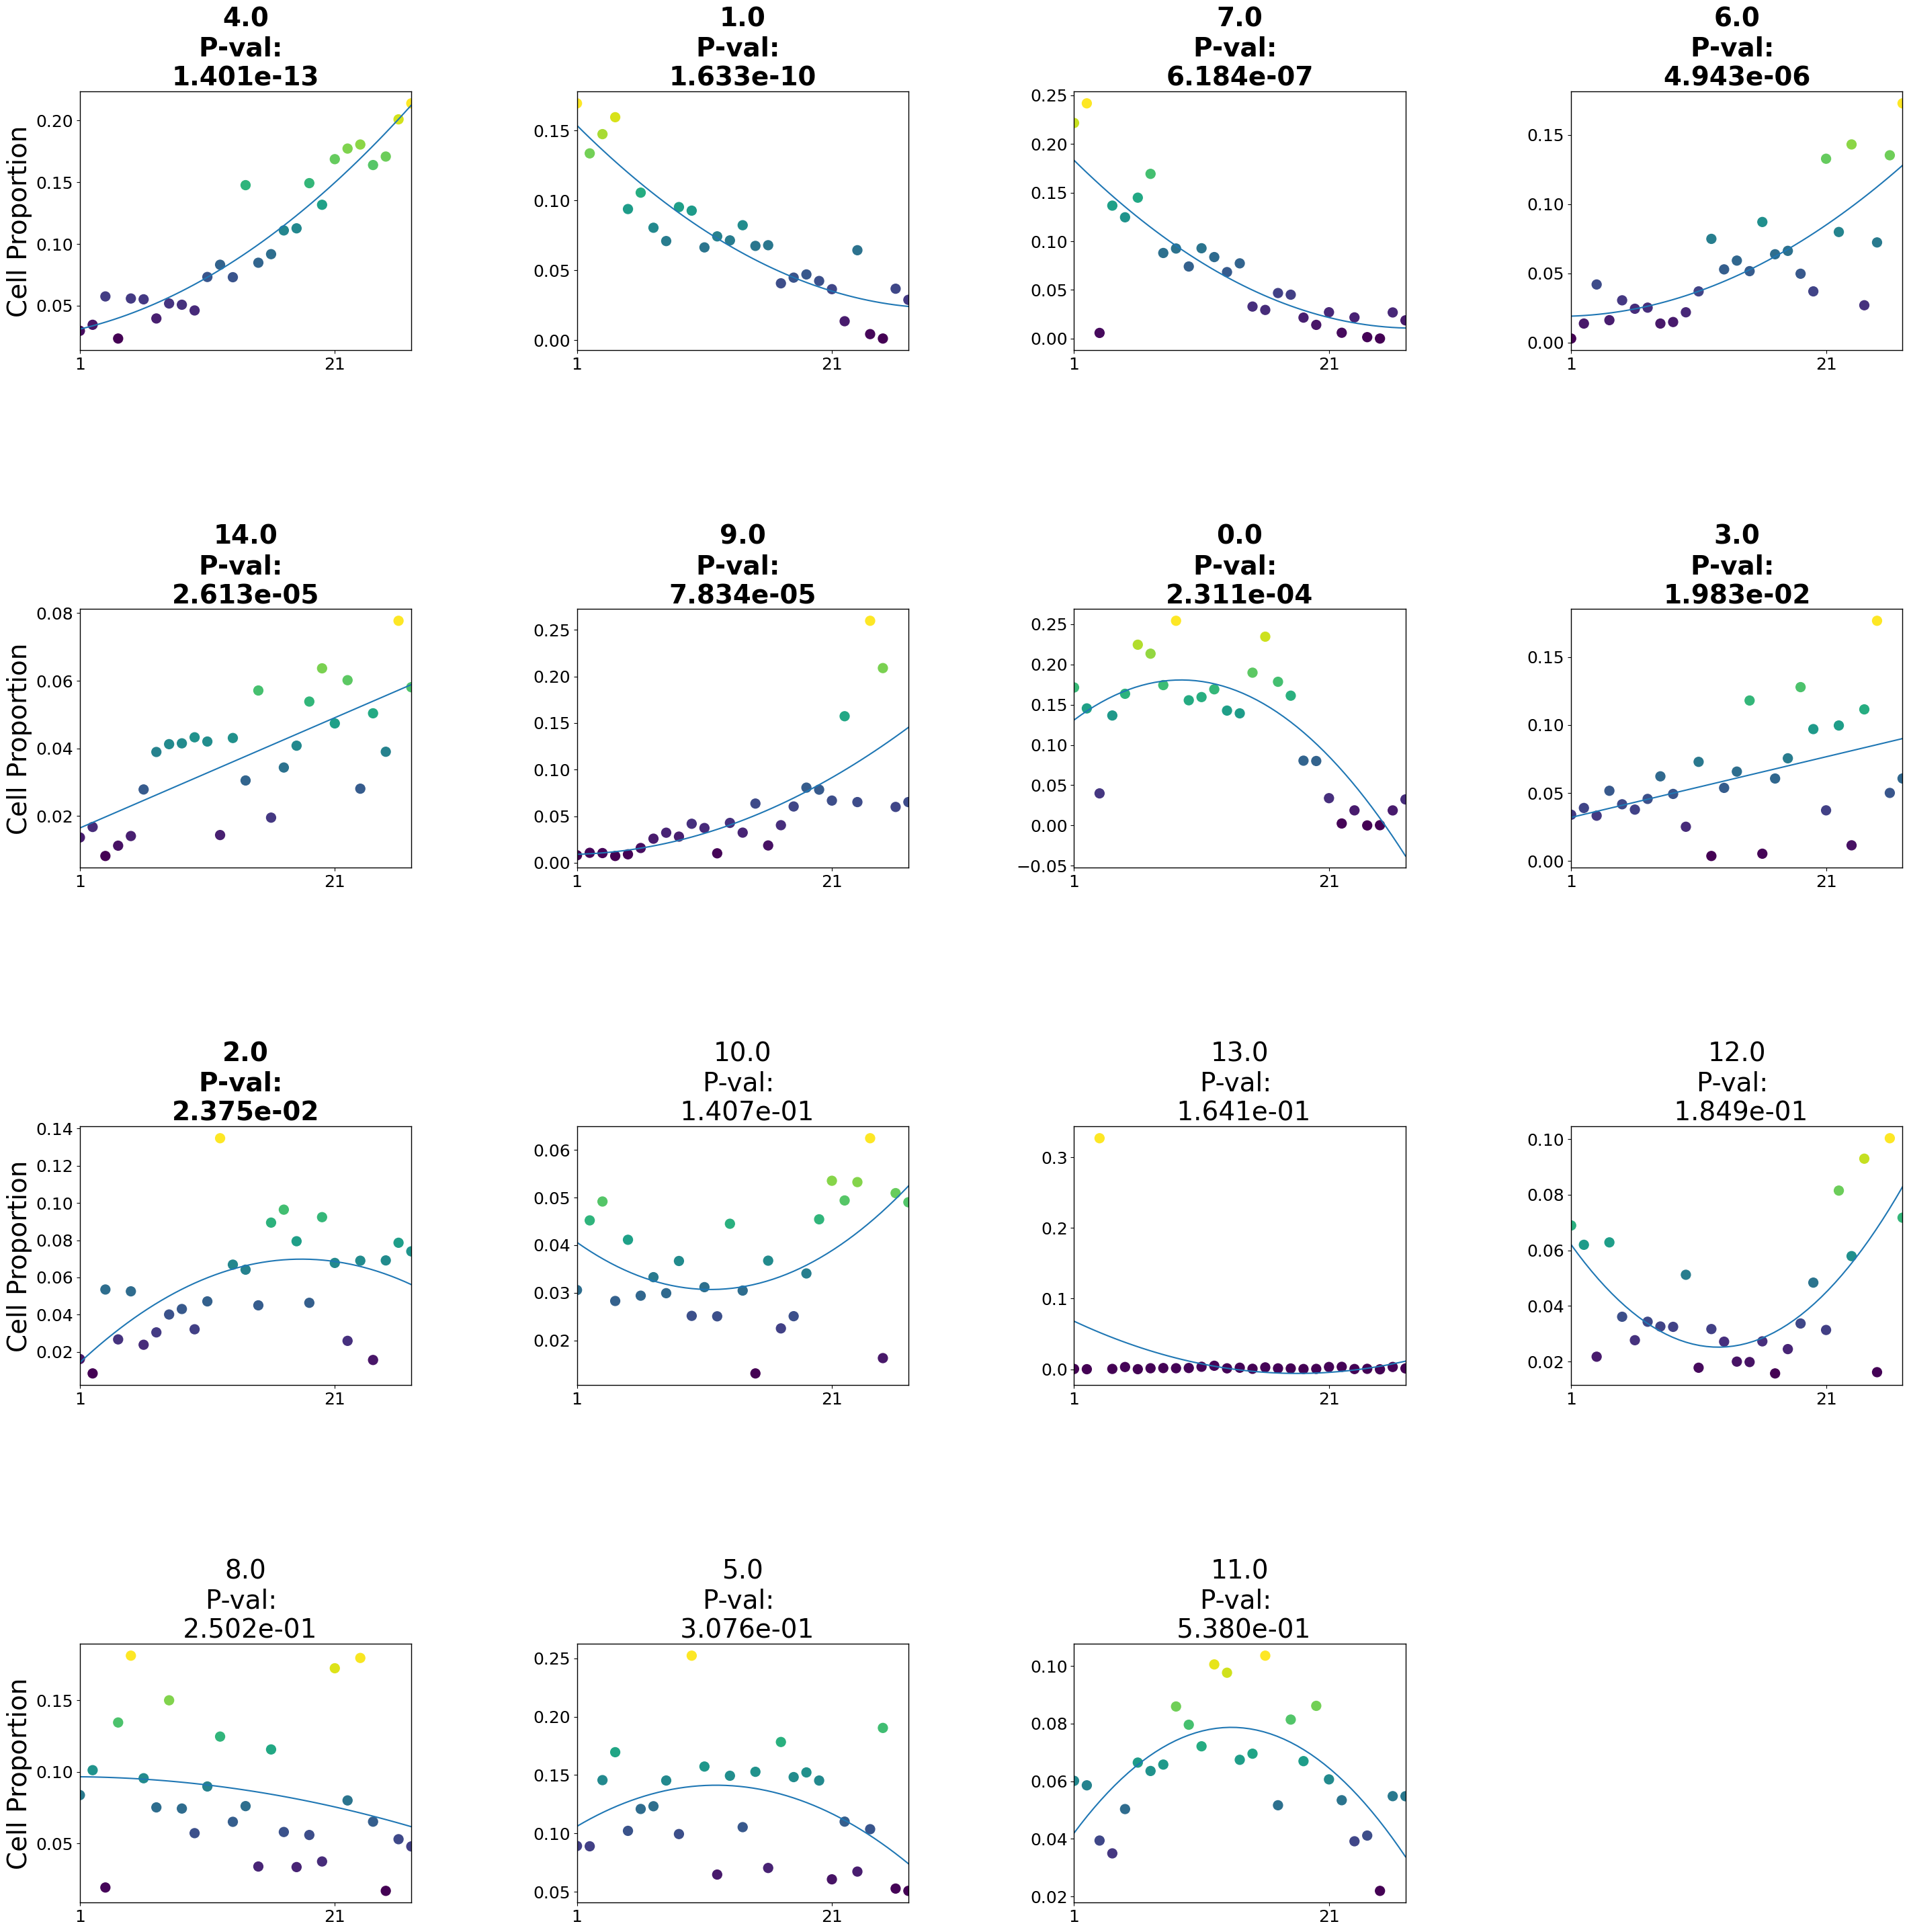

In [221]:
cell_importance(adata,height=35,width=35,fontsize=28,xlim=20,figsize=(5,5))

In [222]:
correlation_categorical_with_trajectory(adata, sample_col = 'Donor', features = ['batch','status',])

,Feature,ANOVA_FStatistic,ANOVA_PValue
0,batch,15.160269,0.000651
1,status,6.239367,0.000681
